# Final Assignment - Canada Housing Prices Analysis
### Group 14
#### Ei Htoo Khaing, Lio, James Nguyen
In this assignment, we will self-answer qeustions about Canadian real estate price trends and investigates how they are influenced by key socioeconomic factors.  
The dataset is retrieved from github [https://github.com/tahczeban/CANADIAN_REAL_ESTATE_PRICES].

We understand that, when submitting this assingment, we are abiding to Seneca's standards of academic honesty.

In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
                    .getOrCreate()

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

In [0]:
from pyspark.sql.functions import avg, round, col, dense_rank, row_number, when
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

### 1: Data Cleaning and Preparation (Filtering)

First, open the files and set the variables. Clean the unnecessary columns or change columns. Filter only the needed year values.

In [0]:
from pyspark.sql.functions import col

house_df = spark.table("avg_house_price")
pop_df = spark.table("population_analysis_sid")
income_df = spark.table("prov_hh_income")
dfcrime_rate = spark.table("crime_rate")

# Remove null values if there's any, then filter out only the years needed to analyse
house_df = house_df.dropna().filter(col('Year') != 2021)
pop_df = pop_df.dropna().filter(col("Year") >= 2015).filter(col("Year") != 2021)
income_df = income_df.dropna().filter(col("Year") >= 2015)
dfcrime_rate = dfcrime_rate.dropna().distinct()

In [0]:
income_df.filter(col('Year') == 2015).orderBy("Province").show()

+----+--------+------+
|Year|Province|Income|
+----+--------+------+
|2015| Alberta|108594|
|2015|      BC| 79234|
|2015|      MB| 72971|
|2015|      NB| 63767|
|2015|      NL| 75183|
|2015|      NS| 64717|
|2015|      NU|110546|
|2015|     NWT|116295|
|2015|     ONT| 79674|
|2015|     PEI| 63660|
|2015|      QC| 61161|
|2015|      SK| 83814|
|2015|      YK| 96529|
+----+--------+------+



In [0]:
pop_df.filter(col('Year') == 2015).orderBy("Province").show()

+----+--------+----------+
|Year|Province|Population|
+----+--------+----------+
|2015|      AB|  16548357|
|2015|      BC|  19082570|
|2015|      MB|   5164103|
|2015|      NB|   3037185|
|2015|      NL|   2113237|
|2015|      NS|   3749412|
|2015|      NU|    145593|
|2015|     NWT|    176998|
|2015|     ONT|  54792403|
|2015|     PEI|    578067|
|2015|      QC|  32691481|
|2015|      SK|   4482873|
|2015|      YK|    149981|
+----+--------+----------+



In [0]:
house_df.filter(col('Year') == 2015).orderBy("Province").show()

+----+--------+---------+
|Year|Province|Avg_price|
+----+--------+---------+
|2015|      AB|   432800|
|2015|      BC|   610000|
|2015|      MB|   283000|
|2015|      NB|   199800|
|2015|      NL|   299300|
|2015|      NS|   256100|
|2015|     ONT|   455000|
|2015|     PEI|   204200|
|2015|      QC|   305800|
|2015|      SK|   332600|
+----+--------+---------+



- AB → Alberta
- BC → British Columbia
- QC → Quebec
- SK → Saskatchewan
- MB → Manitoba
- NB → New Brunswick
- NS → Nova Scotia
- ONT → Ontario 
- PEI → Prince Edward Island
- NL → Newfoundland and Labrador

### 2: Create a new column with the same Format for Province (When/Otherwise operations)

In [0]:
# After checking the housing dataset, only 10 provinces' housing data are recorded. Therefore, I'll filter the "NU, NWT, YK" data from pop_df and income_df
# First, change alberta to AB
from pyspark.sql.functions import when, col

income_df = income_df.withColumn("Province",
    when(col("Province") == "Alberta", "AB")
    .otherwise(col("Province"))
)

#Filter the provinces needed
provinces = ["AB","BC","MB","NB","NL","NS","ONT","PEI","QC", "SK"]

pop_df = pop_df.filter(col("Province").isin(provinces))
income_df = income_df.filter(col("Province").isin(provinces))
pop_df.count()
income_df.count()
house_df.count()


60

### 3: Joining Datasets (Joining and/or unions of dataframes)
 
After preparation, we'll combine all three datasets using join.

In [0]:
# Join datasets
combined_df = house_df \
    .join(pop_df, on = ["Year", "Province"], how = "inner") \
    .join(income_df, on = ["Year", "Province"], how = "inner")

combined_df.show()

+----+--------+---------+----------+------+
|Year|Province|Avg_price|Population|Income|
+----+--------+---------+----------+------+
|2015|      AB|   432800|  16548357|108594|
|2015|      BC|   610000|  19082570| 79234|
|2015|      MB|   283000|   5164103| 72971|
|2015|      NB|   199800|   3037185| 63767|
|2015|      NL|   299300|   2113237| 75183|
|2015|      NS|   256100|   3749412| 64717|
|2015|     ONT|   455000|  54792403| 79674|
|2015|     PEI|   204200|    578067| 63660|
|2015|      QC|   305800|  32691481| 61161|
|2015|      SK|   332600|   4482873| 83814|
|2016|      AB|   425900|  16756614| 99059|
|2016|      BC|   717600|  19386872| 79996|
|2016|      MB|   288800|   5244283| 72772|
|2016|      NB|   207800|   3051063| 65074|
|2016|      NL|   298800|   2117189| 73589|
|2016|      NS|   261800|   3767892| 64931|
|2016|     ONT|   515200|  55411999| 80136|
|2016|     PEI|   214700|    585891| 63992|
|2016|      QC|   316000|  32873351| 62059|
|2016|      SK|   332700|   4535

In [0]:
df_join = dfcrime_rate.join(
    house_df,
    on=["Year", "Province"], # Join by the Year and Province columns
    how="inner"
)
df_join.show()

+----+--------+----------+---------+
|Year|Province|Crime_rate|Avg_price|
+----+--------+----------+---------+
|2015|      AB|      8917|   432800|
|2015|      BC|      8608|   610000|
|2015|      MB|      8926|   283000|
|2015|      NB|      5479|   199800|
|2015|      NL|      6371|   299300|
|2015|      NS|      5727|   256100|
|2015|     ONT|      4022|   455000|
|2015|     PEI|      4750|   204200|
|2015|      QC|      4252|   305800|
|2015|      SK|     12919|   332600|
|2016|      AB|      9026|   425900|
|2016|      BC|      8489|   717600|
|2016|      MB|      9508|   288800|
|2016|      NB|      5276|   207800|
|2016|      NL|      6501|   298800|
|2016|      NS|      5590|   261800|
|2016|     ONT|      4091|   515200|
|2016|     PEI|      5013|   214700|
|2016|      QC|      4233|   316000|
|2016|      SK|     13511|   332700|
+----+--------+----------+---------+
only showing top 20 rows


### 4: GroupBy and Aggregation (Grouping & Aggregating (groupBy))

Then, Group the data by Year and find the average.

In [0]:
from pyspark.sql.functions import avg,round

price_by_year = combined_df.groupBy("Year")\
    .agg(round(avg("Avg_price"),3).alias("Avg_House_Price"))\
        .orderBy("Year")

price_by_year.show()

+----+---------------+
|Year|Avg_House_Price|
+----+---------------+
|2015|       337860.0|
|2016|       357930.0|
|2017|       377630.0|
|2018|       386070.0|
|2019|       387430.0|
|2020|       412000.0|
+----+---------------+



In [0]:

"""
Grouping the dataset by province and aggregating the crime rate and house price
"""
df_province = df_join.groupBy("Province").agg(
                 avg("Crime_rate").alias("avg_crime_rate"),
                 avg("Avg_price").alias("avg_house_price")
             ).orderBy("Province")
df_province.show()

+--------+--------------+---------------+
|Province|avg_crime_rate|avg_house_price|
+--------+--------------+---------------+
|      AB|        9339.4|       427580.0|
|      BC|        8602.4|       740960.0|
|      MB|        9810.8|       294880.0|
|      NB|        5863.2|       209740.0|
|      NL|        6328.6|       290140.0|
|      NS|        5721.6|       269680.0|
|     ONT|        4285.0|       561540.0|
|     PEI|        5229.4|       240600.0|
|      QC|        4209.2|       330060.0|
|      SK|       12995.2|       328660.0|
+--------+--------------+---------------+



In [0]:
"""
Grouping the dataset by year and aggregating the crime rate and house price
"""
df_aggregate = df_join.groupBy("Year").agg(
                 avg("Crime_rate").alias("avg_crime_rate"),
                 avg("Avg_price").alias("avg_house_price")
             ).orderBy("Year")
df_aggregate.show()

+----+--------------+---------------+
|Year|avg_crime_rate|avg_house_price|
+----+--------------+---------------+
|2015|        6997.1|       337860.0|
|2016|        7123.8|       357930.0|
|2017|        7099.5|       377630.0|
|2018|        7215.6|       386070.0|
|2019|        7756.4|       387430.0|
+----+--------------+---------------+



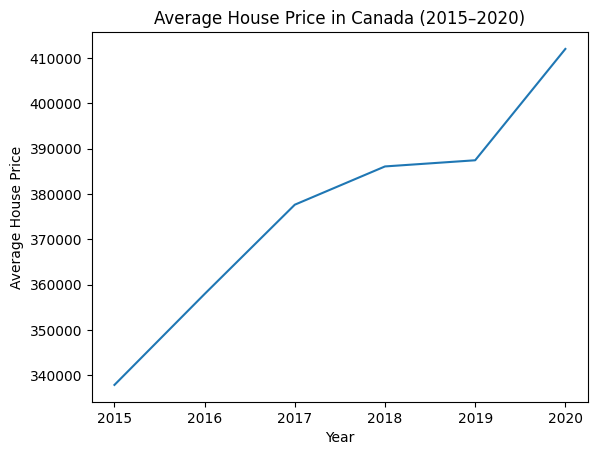

In [0]:
import matplotlib.pyplot as plt

# Convert to pandas
# Need to convert to pandas because PySpark distributes data as clusters across machines for processing 
price_pd = price_by_year.toPandas()

plt.figure()
plt.plot(price_pd["Year"], price_pd["Avg_House_Price"])
plt.xlabel("Year")
plt.ylabel("Average House Price")
plt.title("Average House Price in Canada (2015–2020)")
plt.xticks(price_pd["Year"]) 
plt.show()

In [0]:
income_by_year = combined_df.groupBy("Year")\
    .agg(round(avg("Income"),3).alias("Avg_Income"))\
        .orderBy("Year")
income_by_year.show()

+----+----------+
|Year|Avg_Income|
+----+----------+
|2015|   75277.5|
|2016|   74315.8|
|2017|   76475.4|
|2018|   76648.4|
|2019|   78548.9|
|2020|   84630.2|
+----+----------+



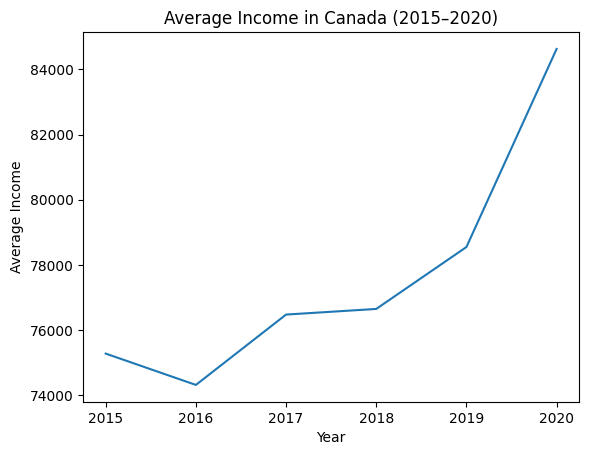

In [0]:
import matplotlib.pyplot as plt

# Convert to pandas
# Need to convert to pandas because PySpark distributes data as clusters across machines for processing 
income_pd = income_by_year.toPandas()

plt.figure()
plt.plot(income_pd["Year"], income_pd["Avg_Income"])
plt.xlabel("Year")
plt.ylabel("Average Income")
plt.title("Average Income in Canada (2015–2020)")
plt.xticks(price_pd["Year"]) 
plt.show()

In [0]:
from pyspark.sql.functions import avg, round, col

pop_by_year = combined_df.groupBy("Year")\
    .agg(round(avg(col("Population")/1000000), 3).alias("Avg_Population_Millions"))\
    .orderBy("Year")

pop_by_year.show()

+----+-----------------------+
|Year|Avg_Population_Millions|
+----+-----------------------+
|2015|                 14.224|
|2016|                 14.373|
|2017|                 14.549|
|2018|                 14.752|
|2019|                 14.966|
|2020|                 15.147|
+----+-----------------------+



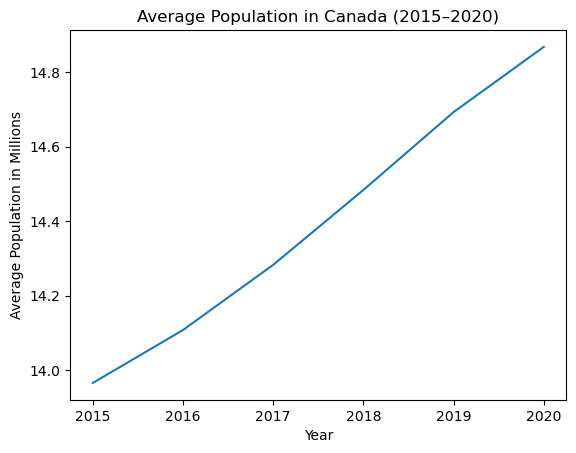

In [0]:
import matplotlib.pyplot as plt

# Convert to pandas
# Need to convert to pandas because PySpark distributes data as clusters across machines for processing 
pop_pd = pop_by_year.toPandas()

plt.figure()
plt.plot(pop_pd["Year"], pop_pd["Avg_Population_Millions"])
plt.xlabel("Year")
plt.ylabel("Average Population in Millions")
plt.title("Average Population in Canada (2015–2020)")
plt.xticks(price_pd["Year"]) 
plt.show()

In [0]:
# Join datasets
combined_avg_df = price_by_year \
    .join(pop_by_year, on = "Year", how = "inner") \
    .join(income_by_year, on = "Year", how = "inner")\
    .orderBy("Year")

combined_avg_df.show()

+----+---------------+-----------------------+----------+
|Year|Avg_House_Price|Avg_Population_Millions|Avg_Income|
+----+---------------+-----------------------+----------+
|2015|     327311.111|                 13.966| 71575.667|
|2016|     350377.778|                 14.108| 71566.556|
|2017|     371833.333|                 14.283| 73630.778|
|2018|     381355.556|                 14.484|   73863.0|
|2019|     383711.111|                 14.693| 75703.556|
|2020|     411011.111|                 14.868| 82091.333|
+----+---------------+-----------------------+----------+



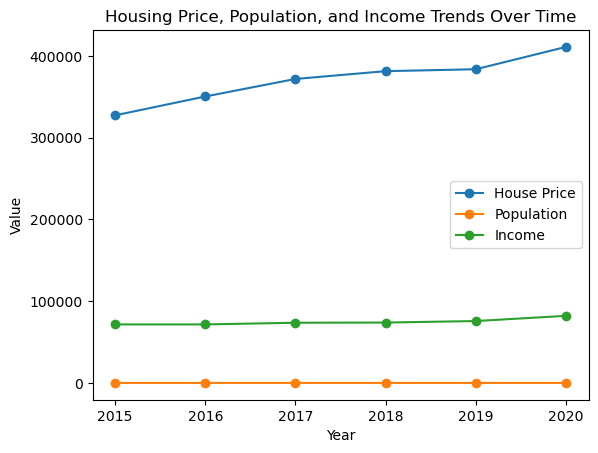

In [0]:
combined_pd = combined_avg_df.toPandas()

plt.figure()
plt.plot(combined_pd["Year"], combined_pd["Avg_House_Price"], marker='o', label="House Price")
plt.plot(combined_pd["Year"], combined_pd["Avg_Population_Millions"], marker='o', label="Population")
plt.plot(combined_pd["Year"], combined_pd["Avg_Income"], marker='o', label="Income")

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Housing Price, Population, and Income Trends Over Time")
plt.xticks(combined_pd["Year"])
plt.legend()

plt.show()

# 5. Window Operations

In [0]:
"""
Moving average over time for each province.
"""
windowSpec = (
    Window
    .partitionBy("Province")
    .orderBy(col("Year"))
    .rowsBetween(-1, 1) # 1 year before, current, 1 year after (3 years window)
)
"""
Calculating the moving average of Crime Rate and Average House Price (3 years window) for each province
"""
df_window = df_join.withColumn(
    "Crime_rate_mean_window",
    round(avg(col("Crime_rate")).over(windowSpec),2)
)

df_window = df_window.withColumn(
    "Avg_price_mean_window",
    round(avg(col("Avg_price")).over(windowSpec),2)
)
df_window.show(50)


+----+--------+----------+---------+----------------------+---------------------+
|Year|Province|Crime_rate|Avg_price|Crime_rate_mean_window|Avg_price_mean_window|
+----+--------+----------+---------+----------------------+---------------------+
|2015|      AB|      8917|   432800|                8971.5|             429350.0|
|2016|      AB|      9026|   425900|               9092.67|             429500.0|
|2017|      AB|      9335|   429800|                9251.0|            428066.67|
|2018|      AB|      9392|   428500|               9584.67|             426400.0|
|2019|      AB|     10027|   420900|                9709.5|             424700.0|
|2015|      BC|      8608|   610000|                8548.5|             663800.0|
|2016|      BC|      8489|   717600|               8395.67|             701000.0|
|2017|      BC|      8090|   775400|               8276.67|            769766.67|
|2018|      BC|      8251|   816300|               8638.33|             792400.0|
|2019|      BC| 

In [0]:
"""
Ranking the crime rate for each province
"""
window_high_crime = Window.partitionBy("Province").orderBy(col("Crime_rate").desc())
window_low_crime = Window.partitionBy("Province").orderBy(col("Crime_rate").asc())

df_ranked = (
    df_join
    .withColumn("row_number_high_crime", row_number().over(window_high_crime))
    .withColumn("rank_low_crime_rate", dense_rank().over(window_low_crime))
)

df_ranked.show()  

+----+--------+----------+---------+---------------------+-------------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|
+----+--------+----------+---------+---------------------+-------------------+
|2015|      AB|      8917|   432800|                    5|                  1|
|2016|      AB|      9026|   425900|                    4|                  2|
|2017|      AB|      9335|   429800|                    3|                  3|
|2018|      AB|      9392|   428500|                    2|                  4|
|2019|      AB|     10027|   420900|                    1|                  5|
|2017|      BC|      8090|   775400|                    5|                  1|
|2018|      BC|      8251|   816300|                    4|                  2|
|2016|      BC|      8489|   717600|                    3|                  3|
|2015|      BC|      8608|   610000|                    2|                  4|
|2019|      BC|      9574|   785500|                

In [0]:
"""
Ranking the house price for each province
"""
window_high_price = Window.partitionBy("Province").orderBy(col("Avg_price").desc())
window_low_price  = Window.partitionBy("Province").orderBy(col("Avg_price").asc())

df_ranked_price = (
    df_ranked
    .withColumn("row_number_high_price", row_number().over(window_high_price))
    .withColumn("rank_low_price", dense_rank().over(window_low_price))
)

df_ranked_price.show()


+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|row_number_high_price|rank_low_price|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|2019|      AB|     10027|   420900|                    1|                  5|                    5|             1|
|2016|      AB|      9026|   425900|                    4|                  2|                    4|             2|
|2018|      AB|      9392|   428500|                    2|                  4|                    3|             3|
|2017|      AB|      9335|   429800|                    3|                  3|                    2|             4|
|2015|      AB|      8917|   432800|                    5|                  1|                    1|             5|
|2015|      BC|      8608|   610000|                    2|              

In [0]:
"""
Finding the best places and time to live
"""
df_ranked_price.filter(
    (col("rank_low_crime_rate") == 1) &
    (col("rank_low_price") == 1)
).show()


+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|row_number_high_price|rank_low_price|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|2015|      MB|      8926|   283000|                    5|                  1|                    5|             1|
|2015|     ONT|      4022|   455000|                    5|                  1|                    5|             1|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+



In [0]:
"""
Finding the worst places and time to live
"""
df_ranked_price.filter(
    (col("rank_low_crime_rate") == 5) &
    (col("rank_low_price") == 5)
).show()

+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|Year|Province|Crime_rate|Avg_price|row_number_high_crime|rank_low_crime_rate|row_number_high_price|rank_low_price|
+----+--------+----------+---------+---------------------+-------------------+---------------------+--------------+
|2019|      MB|     10864|   305200|                    1|                  5|                    1|             5|
|2019|      NB|      6752|   218100|                    1|                  5|                    1|             5|
|2019|      NS|      5873|   282700|                    1|                  5|                    1|             5|
|2019|     ONT|      4544|   630600|                    1|                  5|                    1|             5|
|2019|     PEI|      6279|   277300|                    1|                  5|                    1|             5|
|2016|      SK|     13511|   332700|                    1|              

### Bar Chart Average Crime Rate by Province

In [0]:
pdf_agg = df_aggregate.toPandas()

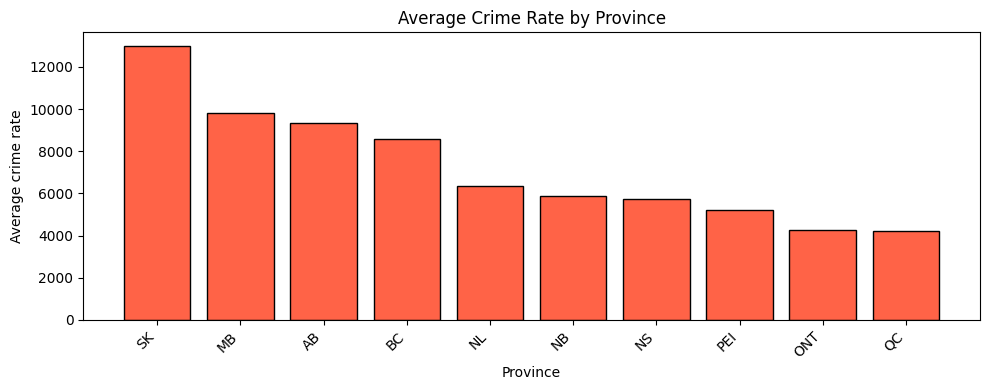

In [0]:
pdf_by_prov = df_province.toPandas()
pdf_by_prov_1 = pdf_by_prov.sort_values("avg_crime_rate", ascending=False)



plt.figure(figsize=(10, 4))
plt.bar(
    pdf_by_prov_1["Province"],
    pdf_by_prov_1["avg_crime_rate"],
    color="tomato",
    edgecolor="black"
)

plt.title("Average Crime Rate by Province")
plt.xlabel("Province")
plt.ylabel("Average crime rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



From 2015 to 2019, both average crime rates and house prices steadily increased over time, and across provinces the average crime rate is highest in Saskatchewan and then gradually decreases toward Quebec and Ontario.

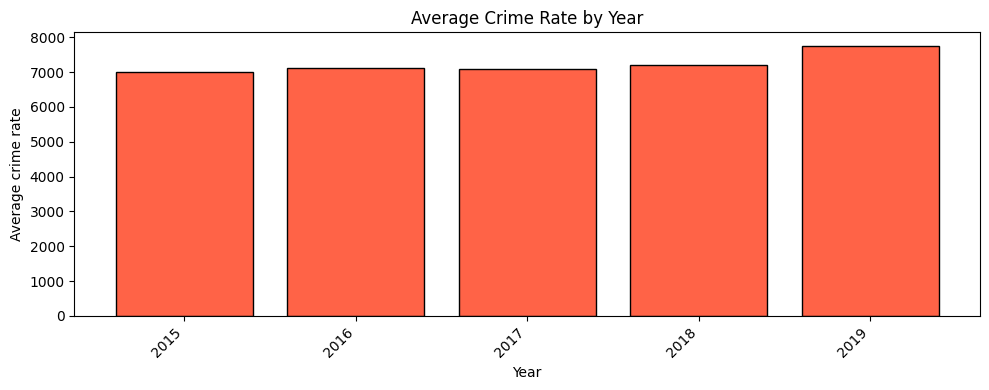

In [0]:
pdf_agg_1 = pdf_agg.sort_values("avg_crime_rate", ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(
    pdf_agg_1["Year"],
    pdf_agg_1["avg_crime_rate"],
    color="tomato",
    edgecolor="black"
)

plt.title("Average Crime Rate by Year")
plt.xlabel("Year")
plt.ylabel("Average crime rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Bar Chart of Average House Price by Province

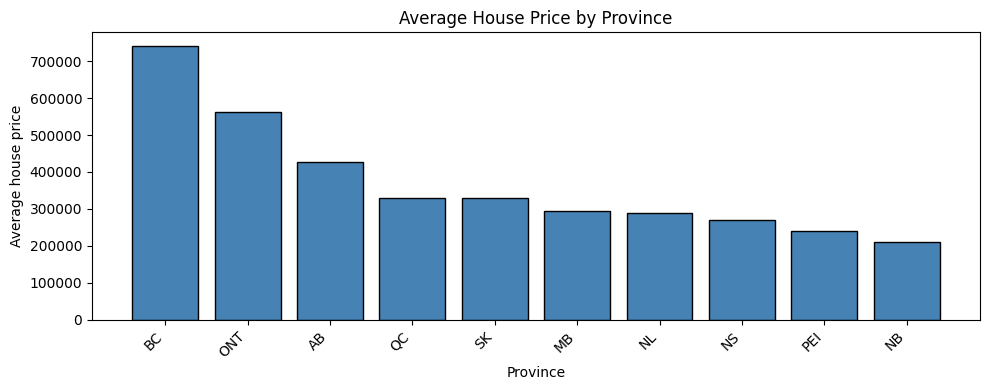

In [0]:
pdf_by_prov_2 = pdf_by_prov.sort_values("avg_house_price", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(
    pdf_by_prov_2["Province"],
    pdf_by_prov_2["avg_house_price"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Average House Price by Province")
plt.xlabel("Province")
plt.ylabel("Average house price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


BC and Ontario have the highest average house prices, and then prices drop steadily across the other provinces, with New Brunswick having the lowest.

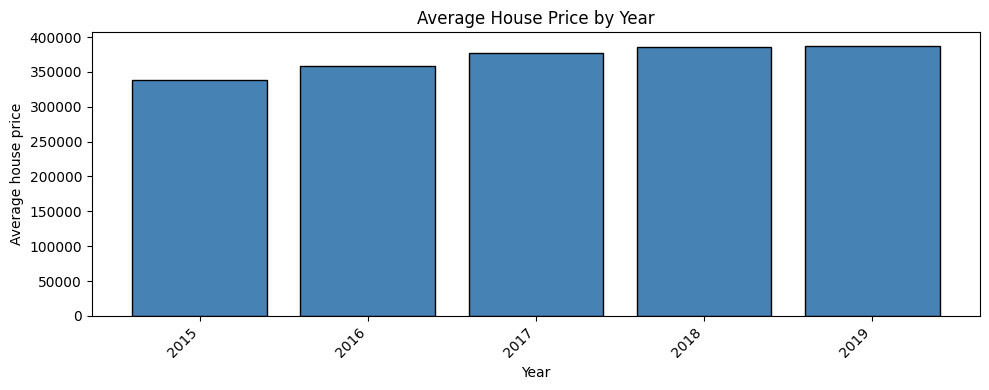

In [0]:
pdf_agg_2 = pdf_agg.sort_values("avg_house_price", ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(
    pdf_agg_2["Year"],
    pdf_agg_2["avg_house_price"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Average House Price by Year")
plt.xlabel("Year")
plt.ylabel("Average house price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()